In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts

from pmt.io import *
from scipy.signal import find_peaks

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.selection import *
from pmt.fit import *
from pmt.fit.core import *

from pmt.fit.poisson import fit_poisson_spe, poisson_npe_fractions
from pmt.fit.bellamy import fit_bellamy_spe





plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


# Select Files


In [3]:
channel="Channel 2"
data_dir = Path("data/WA0089/LED_sweep/260625/850V_525MHz")

# file_name = "led_080" # ok 
file_name = "led_100" # ok
# file_name = "led_120" # ok
# file_name = "led_140" # ok
# file_name = "led_160" # ok
# file_name = "led_180" # ok

# Set to a number for quick iteration, or None to use all matching files.
max_files = None

files = find_pmt_files(data_dir, file_name, max_files=max_files)

for file in files:
    print(file)
print(f"Number of files loaded: {len(files)}")

# save
save_plots = True
save_dir = 'plots_fit'
file_nickname = file_name

data/WA0089/LED_sweep/260625/850V_525MHz/led_100-1.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-10.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-2.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-3.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-4.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-5.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-6.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-7.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-8.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-9.h5
Number of files loaded: 10


In [4]:
chunk_size = 512 #4096
# baseline_window_width_ns          = 20
baseline_window_ns                = (0, 20)
selection_peak_threshold_max_mV   = 0.5

In [5]:
time_ns ,waveforms_mV, df =  load_file_one_go(files, chunk_size, baseline_window_ns, channel)


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                      279006      100.0%        100.0%
peaks in the baseline        278741       99.9%         99.9%


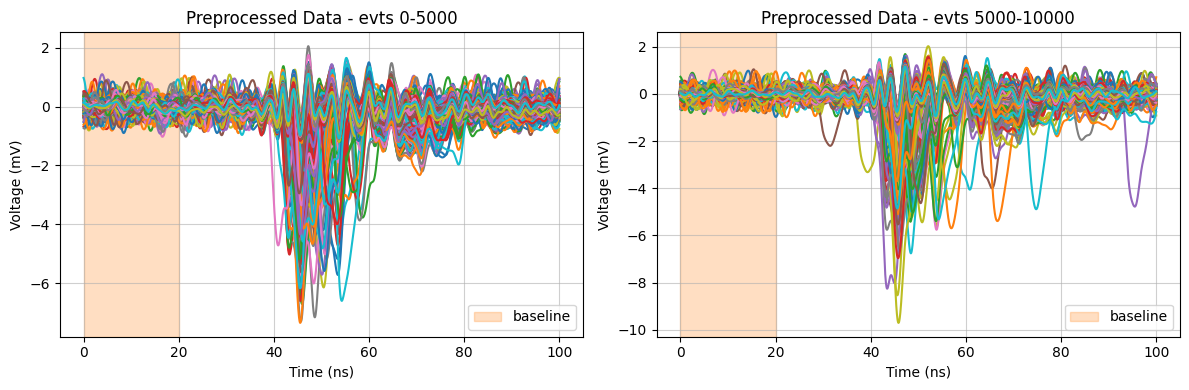

In [6]:
n_to_plot = 5000

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

add_plot_waveforms(axes[0], time_ns, waveforms_mV[:n_to_plot], title=f"Preprocessed Data - evts 0-{n_to_plot}")
axes[0].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[0].legend(loc="lower right")

add_plot_waveforms(axes[1], time_ns, waveforms_mV[n_to_plot:2*n_to_plot], title=f"Preprocessed Data - evts {n_to_plot}-{2*n_to_plot}")
axes[1].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[1].legend(loc="lower right")

fig.tight_layout()
save_plot(fig, save_plots, save_dir, file_nickname,"few_waveforms", Nevents=n_to_plot);

[PosixPath('plots_fit/led_100_charge_all_methods.pdf')]

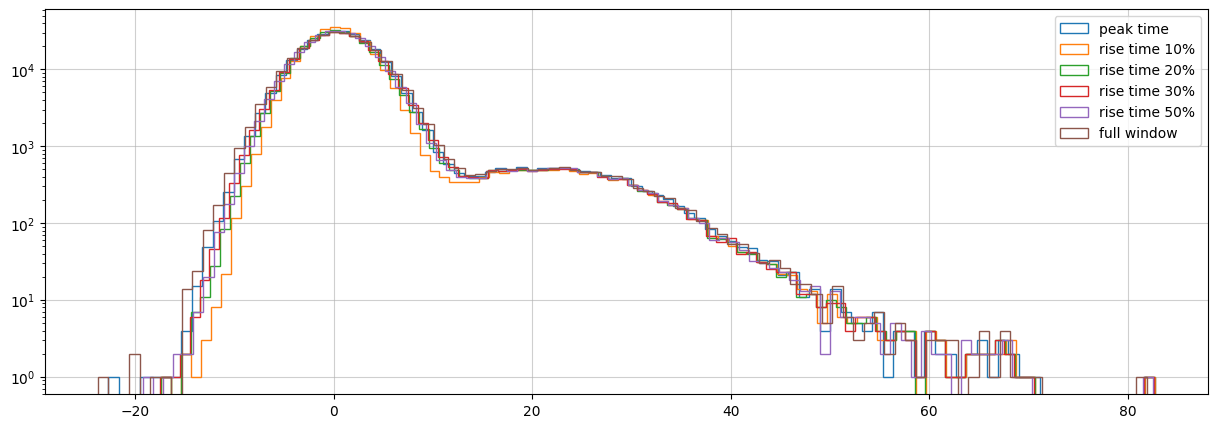

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))


rg = None #(-20, 10)
den=False

axes.hist(df.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes.hist(df.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes.hist(df.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes.hist(df.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes.hist(df.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes.hist(df.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes.set_yscale('log');
axes.legend();

save_plot(fig, save_plots, save_dir, file_nickname, f"charge_all_methods",  Nevents=None)



# Fit one step

In [8]:
charge_mV_ns = df.charge_cfd20_window_mV_ns.values # chose one charge distribution
fit_range_full = (np.min(charge_mV_ns), np.max(charge_mV_ns))
print(f"full range = ({fit_range_full[0]:.2f}, {fit_range_full[1]:.2f})")
fit_range = fit_range_full #(-16, 90)

full range = (-17.44, 82.65)


In [9]:
bins_list = [50, 75, 100, 150, 200, 250, 300, 400, 500, 600, 700, 800, 900, 1000]
_ = scan_binning( charge_mV_ns, bins_list, fit_range=fit_range )
# _ = binning_diagnostics( charge_mV_ns, 250, fit_range=fit_range, verbose=True )

  Bins     Width      Mean    Median    Empty%       <5%     Min     Max
------------------------------------------------------------------------
    50         2    5574.8     146.5      10.0      24.0       0   62608
    75      1.33    3716.5      81.0      10.7      28.0       0   42306
   100         1    2787.4      62.5      13.0      31.0       0   32199
   150     0.667    1858.3      44.5      14.7      34.7       0   21451
   200       0.5    1393.7      29.5      19.0      37.0       0   16108
   250       0.4    1115.0      24.5      19.6      38.4       0   12900
   300     0.334     929.1      20.5      21.3      39.0       0   10748
   400      0.25     696.9      15.5      24.5      41.2       0    8107
   500       0.2     557.5      14.0      26.0      42.4       0    6520
   600     0.167     464.6      11.0      27.2      44.3       0    5438
   700     0.143     398.2       9.0      29.4      45.6       0    4644
   800     0.125     348.4       8.0      30.6     

In [10]:
nbins = 250
_ = binning_diagnostics( charge_mV_ns, nbins, fit_range=fit_range )

Binning diagnostics
----------------------------------------
Entries              : 278741
Bins                 : 250
Bin width            : 0.4004
Min count/bin        : 0
Max count/bin        : 12900
Mean count/bin       : 1114.96
Median count/bin     : 24.50
Empty bins           : 49 (19.6%)
Bins with <5 counts  : 96 (38.4%)


## Poisson

Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         278741.0000 278175.5380     527.4393   [139370.5, 557482.0]   False
mu_pe                0.0300      0.0463       0.0006             [0.0, 5.0]   False
q0_mV_ns             0.3000      0.3670       0.0067           [-6.0, 10.0]   False
sigma0_mV_ns         2.5000      3.3169       0.0051            [0.0, 50.0]   False
q1_mV_ns            29.0000     19.0732       0.1885            [1.0, 40.0]   False
sigma1_mV_ns        12.0000      8.8776       0.1425            [0.2, 20.0]   False

 Gain is 2.38e+06 +-2.35e+04 for Q1 = 19.07319130093553


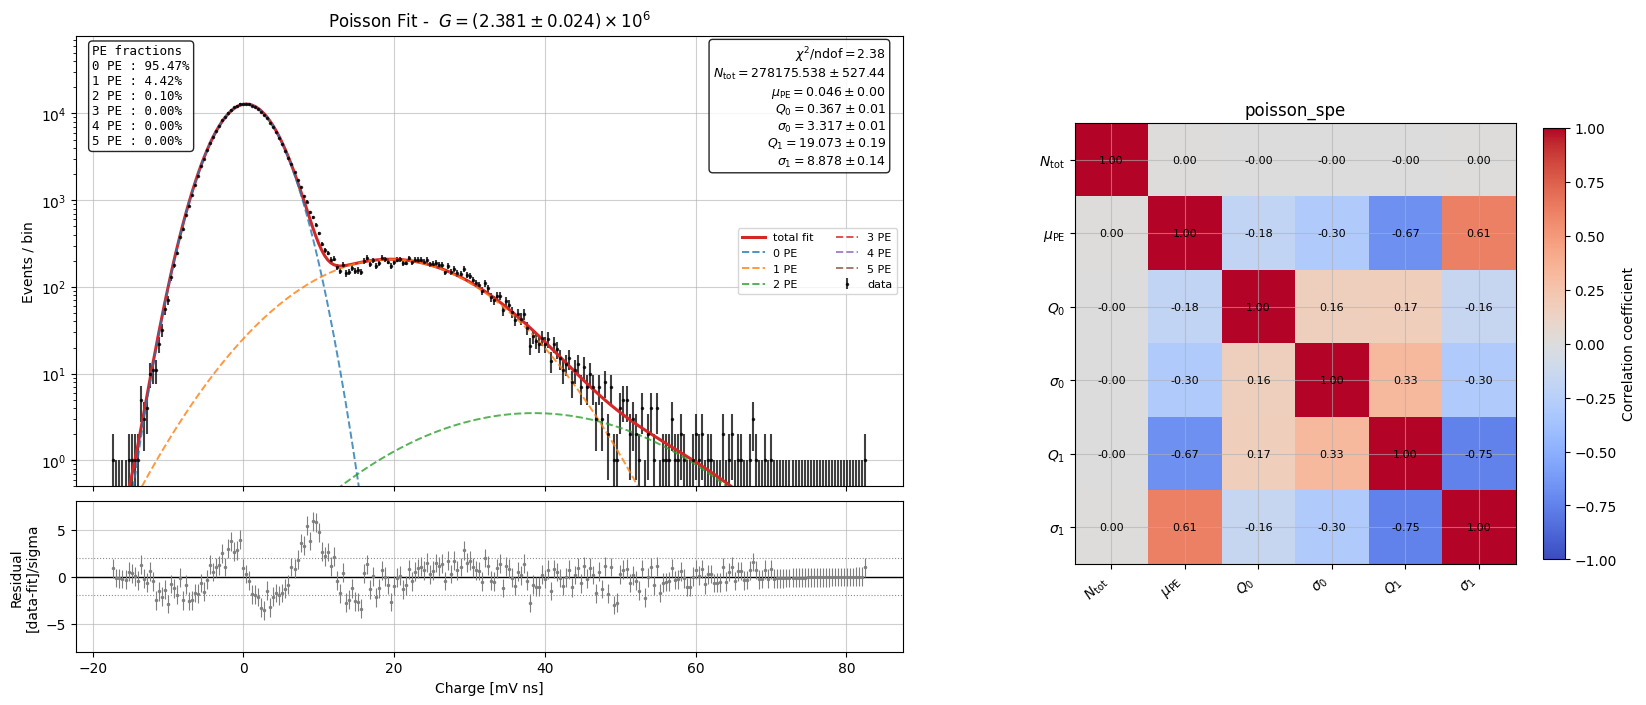

In [11]:
maxPE = 5

p0_poisson = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    # Set isFixed=True to hold a parameter at the initial value during the fit.
    "n_total":      [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 2.0 * len(charge_mV_ns), False],
    "q0_mV_ns":     [0.3, -6.0, 10.0,  False],
    "sigma0_mV_ns": [2.5, 1e-4, 50.0,  False],
    "q1_mV_ns":     [29.0, 1.0, 40.0,  False],
    "sigma1_mV_ns": [12.0, 0.2, 20.0,  False],
    "mu_pe":        [0.03, 0.001, 5.0, False],
}

fit_poisson = fit_poisson_spe( charge_mV_ns, p0=p0_poisson, max_pe=maxPE,
                               bins=nbins, #default 250
                            #    fit_range=fit_range_full
                               fit_range=fit_range
)

# table_poisson = fit_result_table(fit_poisson)
print_fit_result_table(fit_poisson)
fit_poisson["diagnostics"]

G, G_err = compute_gain(fit_poisson['parameters']['q1_mV_ns'], fit_poisson['errors']['q1_mV_ns'])
print(f"\n Gain is {G:.3g} +-{G_err:.2e} for Q1 = {fit_poisson['parameters']['q1_mV_ns']}")
exp = 6
G_scaled = G / 10**exp
Gerr_scaled = G_err / 10**exp
title = fr"Poisson Fit -  $G = ({G_scaled:.3f} \pm {Gerr_scaled:.3f}) \times 10^{exp}$"

fig, ax_fit, ax_resid, ax_corr = plot_fit_summary( fit_poisson, title=title, shrink_colorbar=0.7, component_visibility_fraction=0, logscale=True,
                                                  show_event_fractions=True, max_fraction_pe=maxPE) 
save_plot(fig, save_plots, save_dir, file_nickname, f"fit_Poisson_{nbins}bins",  Nevents=None);






## Bellamy

Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         278741.0000 278557.7068     527.7990   [139370.5, 557482.0]   False
mu_pe                0.0300      0.0395       0.0007             [0.0, 5.0]   False
q0_mV_ns             0.2700     -0.3037       0.1655           [-6.0, 10.0]   False
sigma0_mV_ns         2.3000      3.1229       0.0275            [0.0, 50.0]   False
q1_mV_ns            30.0000     21.2322       0.2107            [5.0, 50.0]   False
sigma1_mV_ns        12.0000      7.5760       0.1582            [0.2, 30.0]   False
w                    0.2000      0.4620       0.1333             [0.0, 1.0]   False
alpha                0.3000      0.6387       0.0439            [0.0, 10.0]   False
[]

 Gain is 2.65e+06 +-2.63e+04 for Q1 = 21.232246516752124


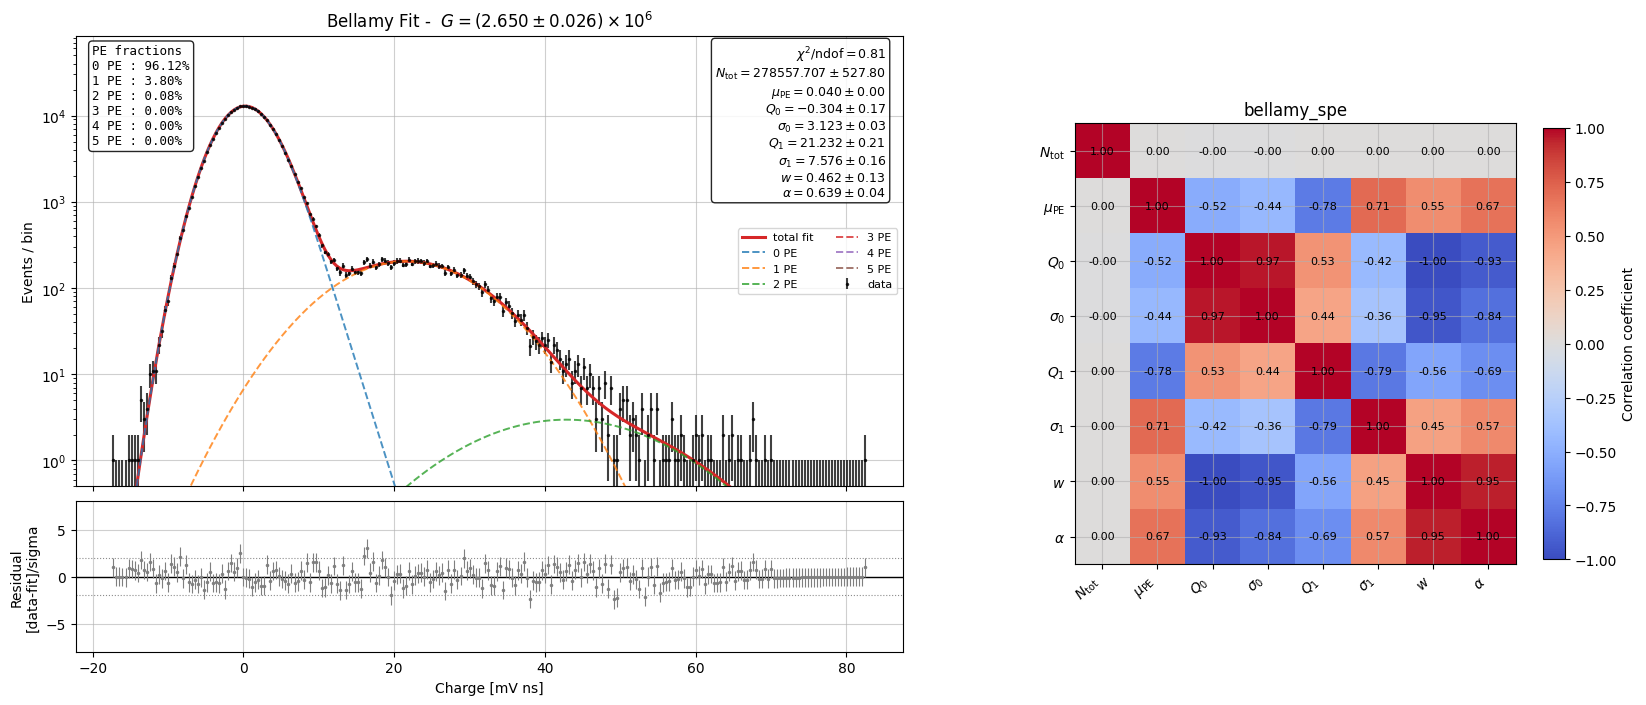

In [12]:
maxPE = 5

p0_bellamy = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    "n_total":      [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 2.0 * len(charge_mV_ns), False],
    "q0_mV_ns":     [0.27, -6.0, 10.0,  False],
    "sigma0_mV_ns": [2.3, 1e-4, 50.0,   False],
    "q1_mV_ns":     [30.0, 5.0, 50.0,   False],
    "sigma1_mV_ns": [12.0, 0.2, 30.0,   False],
    "mu_pe":        [0.03, 0.001, 5.0,  False],
    "w":            [0.2, 0., 1.,       False], # probability that a measured signal is accompanied by a type-2 bkg process 
    # "w":            [1., 0., 1.,       True], # probability that a measured signal is accompanied by a type-2 bkg process 
    "alpha":        [0.3, 0., 10.,      False], # coeff. of the exponential decay of type 2-background (positive)
}

fit_bellamy = fit_bellamy_spe(
    charge_mV_ns,
    p0=p0_bellamy,
    max_pe=maxPE,
    bins=nbins,
    fit_range=fit_range
    # fit_range=fit_range_full
)

print_fit_result_table(fit_bellamy)
print(fit_bellamy["diagnostics"])

G, G_err = compute_gain(fit_bellamy['parameters']['q1_mV_ns'], fit_bellamy['errors']['q1_mV_ns'])
print(f"\n Gain is {G:.3g} +-{G_err:.2e} for Q1 = {fit_bellamy['parameters']['q1_mV_ns']}")

exp = 6
G_scaled = G / 10**exp
Gerr_scaled = G_err / 10**exp
title = fr"Bellamy Fit -  $G = ({G_scaled:.3f} \pm {Gerr_scaled:.3f}) \times 10^{exp}$"

fig, ax_fit, ax_resid, ax_corr = plot_fit_summary( fit_bellamy, title=title, shrink_colorbar=0.7, component_visibility_fraction=0, logscale=True,
                                                  show_event_fractions=True, max_fraction_pe=maxPE) 
save_plot(fig, save_plots, save_dir, file_nickname, f"fit_Bellamy_{nbins}bins",  Nevents=None);


